In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


Explaratory data analysis using python

In [5]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Kumil\Documents\GitHub\insurance-rsik-analytics\data\MachineLearningRating_v3.txt",
    sep="|",        # pipe delimiter
    header=0        # first row contains column names
)

# Clean column names
df.columns = df.columns.str.strip()


C:\Users\Kumil\AppData\Local\Temp\ipykernel_11780\1681695077.py:3: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

In [7]:
# Quick overview of columns and data types
df.info()

# First few rows
df.head()

# Summary statistics for numeric and categorical features
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1000098,1000098,1000098,1000098,1000098,1000098,854137,959866,...,1000098,1000098,1000098,1000098,1000098,1000098,1000098,1000098,1.000098e+06,1.000098e+06
unique,NaN,NaN,23,2,4,6,5,1,11,3,...,13,28,22,14,5,4,1,1,NaN,NaN
top,NaN,NaN,2015-08-01 00:00:00,False,,Individual,Mr,English,First National Bank,Current account,...,No excess,Passenger Liability,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,NaN,NaN
freq,NaN,NaN,106747,995075,895210,911929,933555,1000098,260811,597938,...,791235,104158,104183,824124,828125,915028,1000098,1000098,NaN,NaN
mean,1.048175e+05,7.956682e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.192982e+01,0.000000e+00


In [8]:
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')


In [9]:
# Check for missing values
df[['TotalPremium', 'TotalClaims']].isnull().sum()

# Check for zero values
(df['TotalPremium'] == 0).sum(), (df['TotalClaims'] == 0).sum()


(np.int64(381634), np.int64(997305))

C:\Users\Kumil\AppData\Local\Temp\ipykernel_11780\3874813310.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_loss.values, y=province_loss.index, palette="viridis")


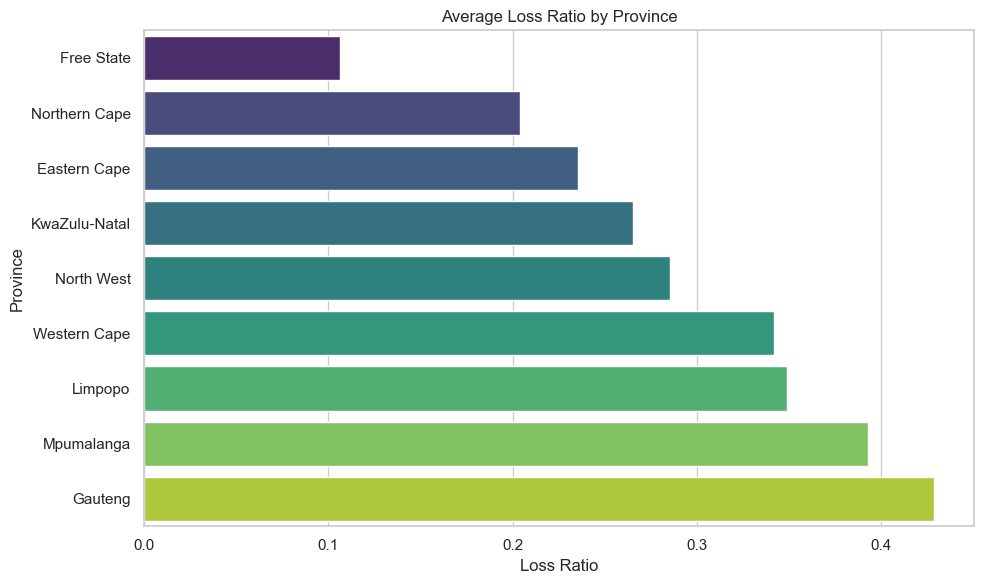

In [10]:
# Filter valid rows
df_valid = df[df['TotalPremium'] > 0].copy()
df_valid['LossRatio'] = df_valid['TotalClaims'] / df_valid['TotalPremium']

# Group by Province
province_loss = df_valid.groupby('Province')['LossRatio'].mean().sort_values()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=province_loss.values, y=province_loss.index, palette="viridis")
plt.title("Average Loss Ratio by Province")
plt.xlabel("Loss Ratio")
plt.ylabel("Province")
plt.tight_layout()
plt.show()


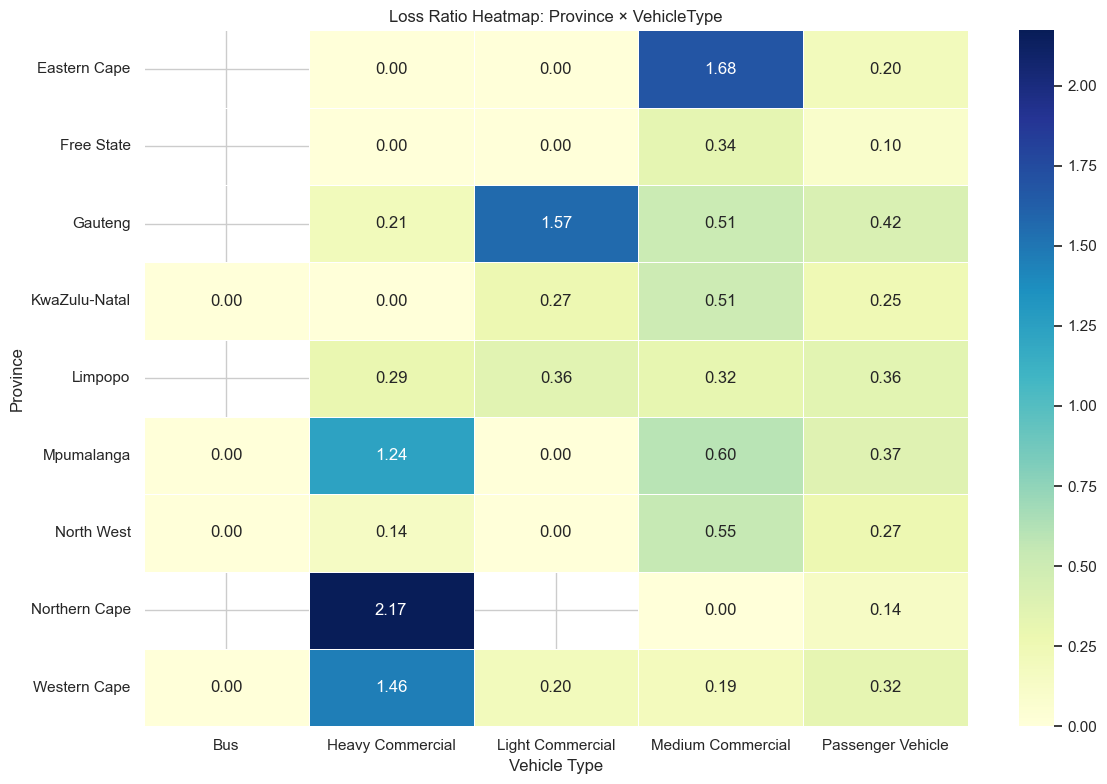

In [11]:
# Group by Province and VehicleType
heatmap_data = df_valid.groupby(['Province', 'VehicleType'])['LossRatio'].mean().unstack()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("Loss Ratio Heatmap: Province × VehicleType")
plt.xlabel("Vehicle Type")
plt.ylabel("Province")
plt.tight_layout()
plt.show()


In [12]:
# Keep only rows with valid premiums
df_valid = df[df['TotalPremium'] > 0].copy()

# Calculate Loss Ratio
df_valid['LossRatio'] = df_valid['TotalClaims'] / df_valid['TotalPremium']

# Portfolio-level loss ratio
portfolio_loss_ratio = df_valid['LossRatio'].mean()
print("Portfolio Loss Ratio:", portfolio_loss_ratio)



Portfolio Loss Ratio: 0.3500476647582784


C:\Users\Kumil\AppData\Local\Temp\ipykernel_11780\1598749438.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Gender", y="TotalClaims", data=df_valid, palette="Set2")


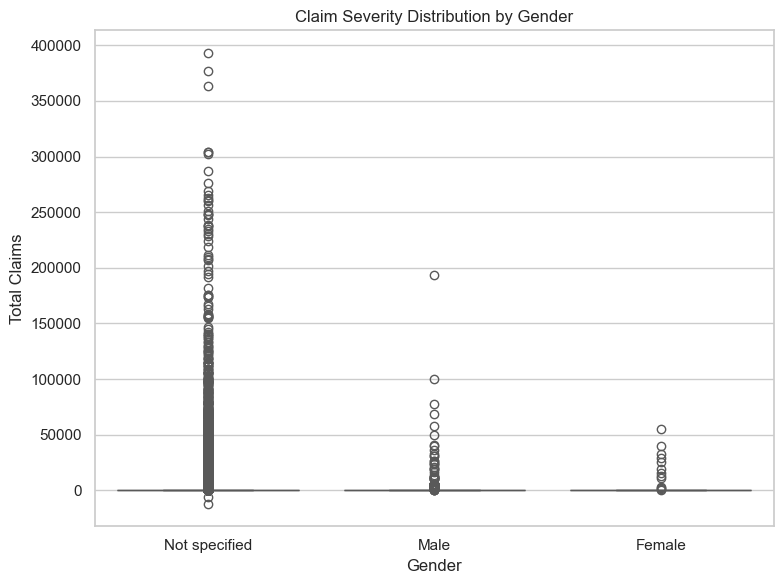

In [13]:
plt.figure(figsize=(8,6))
sns.boxplot(x="Gender", y="TotalClaims", data=df_valid, palette="Set2")
plt.title("Claim Severity Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Claims")
plt.tight_layout()
plt.show()


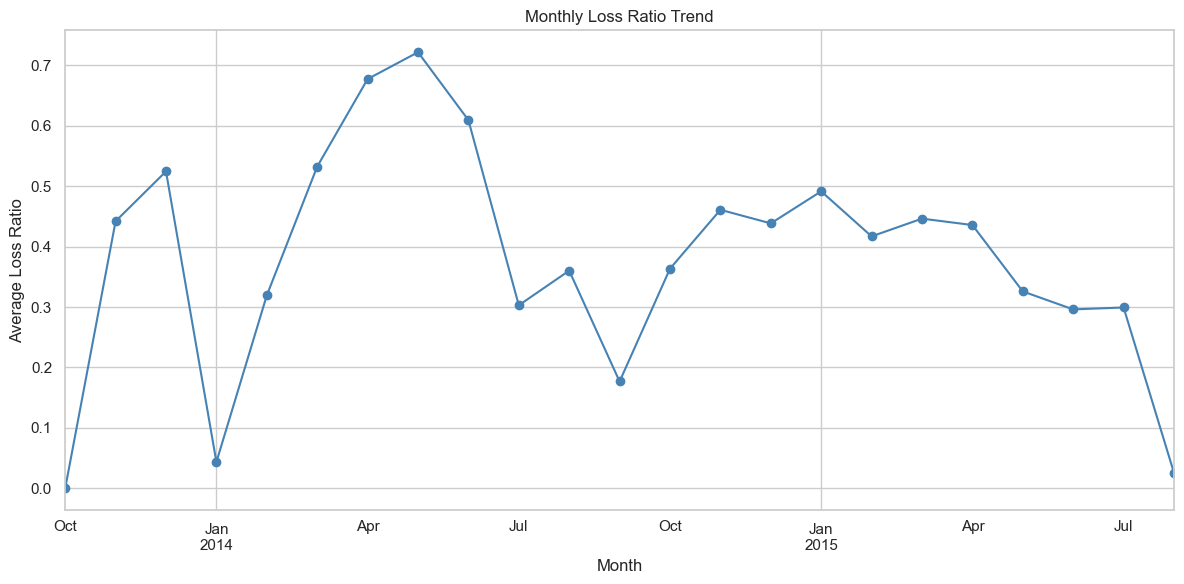

In [14]:
# Group by month
monthly_loss = df_valid.groupby('TransactionMonth')['LossRatio'].mean()

# Plot
plt.figure(figsize=(12,6))
monthly_loss.plot(marker='o', linestyle='-', color='steelblue')
plt.title("Monthly Loss Ratio Trend")
plt.xlabel("Month")
plt.ylabel("Average Loss Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()
